<a href="https://colab.research.google.com/github/ouzkalem/DLSG/blob/HW1/Assignment1_1_debugging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: The Broken Experiment

## Debugging a Failing Deep Learning Pipeline

---

### Background

Your colleague has been trying to train a Multi-Layer Perceptron (MLP) to predict **California housing prices** using the classic California Housing dataset. However, their training pipeline is producing terrible results — the loss explodes, the predictions are nonsensical, and they can't figure out why.

They've asked you for help. Your job is to **find and fix all the bugs** in this notebook.

### Instructions

1. **Read through the entire notebook** before making changes. Understand the intent of each cell.
2. **Identify at least 6 bugs** across data preprocessing, model architecture, loss function, training loop, and evaluation.
3. For **each bug you find**, add a markdown cell explaining:
   - What the bug is
   - Why it causes training to fail (cite the relevant theory)
   - How you fixed it

### Hints

The bugs fall into these categories:
- **Data** (2 bugs)
- **Model Architecture** (1 bug)
- **Loss / Optimization** (2 bugs)
- **Evaluation / Methodology** (1 bug)

Good luck!

## Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.9.0+cu128
Device: cuda


## Load and Prepare the Data

We load the California Housing dataset. It contains 8 features (median income, house age, average rooms, etc.) and the target is the **median house value** (in units of $100,000).

In [2]:
# Load dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

print("Feature columns:", list(X.columns))
print("Dataset shape:", X.shape)
print("Target range: [{:.2f}, {:.2f}]".format(y.min(), y.max()))

Feature columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Dataset shape: (20640, 8)
Target range: [0.15, 5.00]


### 1. Bug

I identified the first bug, which is a data leakage issue. The target variable is being included as an input feature to the model. But this lead to an erroneously perfect (not correct) performance. I fix this with the input features do not contain the target variable.

In [3]:
# Add target to the dataframe for "convenience"
# X['MedHouseVal'] = y   I changed this line with comment
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("Number of input features:", X_train.shape[1])

Training set size: (16512, 8)
Test set size: (4128, 8)
Number of input features: 8


### 2. Bug

Features were very different scales and this cause hinder training. To solve this problem I implement implement feature scaling (standardization). By applying StandardScaler, which normalizes each feature to have a mean of 0 and a standard deviation of 1, we ensure that:
- All features contribute equally to the gradient updates.
- The optimization process is more efficient and stable.
- The model converges faster and to a better solution.


In [4]:
from sklearn.preprocessing import StandardScaler
# For scaled data, new lines added.
# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors — feeding raw features directly
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("Feature sample (first row):", X_train_tensor[0])
print("Feature means (after scaling):", X_train_tensor.mean(dim=0))
print("Feature stds (after scaling):", X_train_tensor.std(dim=0))

Feature sample (first row): tensor([-0.3262,  0.3485, -0.1749, -0.2084,  0.7683,  0.0514, -1.3728,  1.2726])
Feature means (after scaling): tensor([-1.5017e-09,  9.2410e-09, -1.1551e-10,  0.0000e+00, -6.9308e-10,
        -9.2410e-10,  2.3103e-09,  0.0000e+00])
Feature stds (after scaling): tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


## Define the Model

We build a simple MLP with 3 hidden layers for regression.

### 3. Bug

Model used a Softmax activation in the final layer, which isn't suitable for predicting continuous housing prices. This was crucial because it is a regression task, not a classification task. For predicting continuous values like house prices, a linear output layer is the standard and correct choice, allowing the model to make predictions across the entire possible range of the target variable. But Softmax is useful for classification tasks where probabilities are needed.

In [5]:
class HousingMLP(nn.Module):
    def __init__(self, input_dim):
        super(HousingMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1) # Removed Softmax here
            # nn.Softmax(dim=1)  # Output activation for regression
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train_tensor.shape[1]
model = HousingMLP(input_dim)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

HousingMLP(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 11,521


## Define Loss and Optimizer

### 4. Bug

Again CrossEntropyLoss suit for classification problems, not predicting continuous values like housing prices.Mean Squared Error Loss is a standard and appropriate loss function for regression tasks.

### 5. Bug

The training loss was 0.0000 for every epoch and it was a clear error! This happened because the learning rate is way too high, causing the model to diverge or the loss to become NaN instantly.

In [6]:
# Loss function for our regression task
# criterion = nn.CrossEntropyLoss()
criterion = nn.MSELoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001) # lr changed 10 to 0.001

## Training Loop

In [7]:
def train_model(model, train_loader, criterion, optimizer, epochs=50):
    """
    Standard training loop.
    Returns a list of average training loss per epoch.
    """
    model.train()
    train_losses = []

    for epoch in range(epochs):
        epoch_loss = 0.0
        num_batches = 0

        for X_batch, y_batch in train_loader:
            # Forward pass
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

        avg_loss = epoch_loss / num_batches
        train_losses.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] — Train Loss: {avg_loss:.4f}")

    return train_losses

In [8]:
# Run training
NUM_EPOCHS = 50
losses = train_model(model, train_loader, criterion, optimizer, epochs=NUM_EPOCHS)

Epoch [10/50] — Train Loss: 0.3080
Epoch [20/50] — Train Loss: 0.2742
Epoch [30/50] — Train Loss: 0.2540
Epoch [40/50] — Train Loss: 0.2445
Epoch [50/50] — Train Loss: 0.2389


## Evaluate the Model

 ### 6. Bug

 Model was only evaluating on the training data, which doesn't tell us how well it on new data. This can be hide overfitting! So adding test results gives real sitution.

In [9]:
def evaluate_model(model, data_loader):
    """
    Evaluate model and return MSE and MAE.
    """
    model.eval()
    all_preds = []
    all_targets = []

    for X_batch, y_batch in data_loader:
        with torch.no_grad():
            preds = model(X_batch)
        all_preds.append(preds)
        all_targets.append(y_batch)

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    mse = torch.mean((all_preds - all_targets) ** 2).item()
    mae = torch.mean(torch.abs(all_preds - all_targets)).item()
    return mse, mae

# Here added test results
train_mse, train_mae = evaluate_model(model, train_loader)
test_mse, test_mae = evaluate_model(model, test_loader)

print("=" * 50)
print("          MODEL EVALUATION RESULTS")
print("=" * 50)
print(f"  Train MSE: {train_mse:.4f}")
print(f"  Train MAE: {train_mae:.4f}")
print(f"  Test MSE:  {test_mse:.4f}")
print(f"  Test MAE:  {test_mae:.4f}")
print("=" * 50)
# print("\nThe model is performing great!") it was not real :)
print("Now you have a more realistic view of performance!")

          MODEL EVALUATION RESULTS
  Train MSE: 0.2277
  Train MAE: 0.3218
  Test MSE:  0.2594
  Test MAE:  0.3426
Now you have a more realistic view of performance!


## Visualize Training

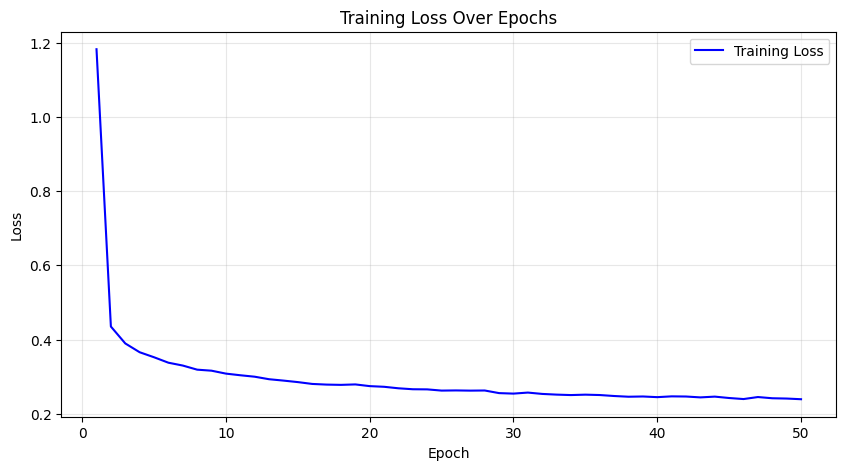

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), losses, label='Training Loss', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()